In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
df = pd.read_csv('../data/hybrid_park_dataset.csv',
                 parse_dates=['Timestamp'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        8760 non-null   datetime64[us]
 1   Hour_of_Day      8760 non-null   int64         
 2   Temperature_C    8760 non-null   float64       
 3   Cloud_Cover_Pct  8760 non-null   float64       
 4   Demand_MW        8760 non-null   float64       
 5   Solar_MW         8760 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 410.8 KB


In [ ]:
def create_time_features(df):
    """Creates time-series features from a datetime index."""
    df['hour'] = df['Timestamp'].dt.hour
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['day_of_year'] = df['Timestamp'].dt.dayofyear
    df['month'] = df['Timestamp'].dt.month
    df['year'] = df['Timestamp'].dt.year
    

    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

def create_cyclical_features(df):
    """Creates cyclical features for time-based attributes."""

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.0)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.0)
    
    return df

df = create_time_features(df)
df = create_cyclical_features(df)

df.head()

Feature engineering complete. New columns added:


,Timestamp,Hour_of_Day,Temperature_C,Cloud_Cover_Pct,Demand_MW,Solar_MW,hour,day_of_week,day_of_year,month,year,is_weekend,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
0,2025-01-01 00:00:00,0,0.000000,0.109799,997.234714,0.0,0,2,1,1,2025,0,0.000000,1.000000,0.017213,0.999852
1,2025-01-01 01:00:00,1,0.000000,0.008713,995.317261,0.0,1,2,1,1,2025,0,0.258819,0.965926,0.017213,0.999852
2,2025-01-01 02:00:00,2,3.177260,0.003088,1015.348695,0.0,2,2,1,1,2025,0,0.500000,0.866025,0.017213,0.999852
3,2025-01-01 03:00:00,3,5.047088,0.027274,1010.851201,0.0,3,2,1,1,2025,0,0.707107,0.707107,0.017213,0.999852
4,2025-01-01 04:00:00,4,8.508635,0.064792,961.734395,0.0,4,2,1,1,2025,0,0.866025,0.500000,0.017213,0.999852


In [ ]:
FEATURES = [
    'Temperature_C',
    'Cloud_Cover_Pct',
    'hour_sin',
    'hour_cos',
    'day_of_year_sin',
    'day_of_year_cos'
]


TARGET = 'Solar_MW'

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES],
    df[TARGET],
    test_size=0.2,
    random_state=42, 
    shuffle=False
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")

Training set shape: (7008, 6)
Test set shape:     (1752, 6)


In [ ]:
model = xgb.XGBRegressor(
    n_estimators=200,     
    learning_rate=0.05,      
    max_depth=5,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    objective='reg:squarederror',
    n_jobs=-1,               
    random_state=42
)

print("▶ Training the XGBoost model...")

model.fit(X_train, y_train)

print("✓ Model training complete.")

▶ Training the XGBoost model...
✓ Model training complete.


In [11]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"R-squared (R²) Score:      {r2:.4f}")

Mean Absolute Error (MAE): 7.04 MW
R-squared (R²) Score:      0.9984


In [13]:
print("Train R²:", r2_score(y_train, model.predict(X_train)))
print("Test R²:",  r2_score(y_test, model.predict(X_test)))

Train R²: 0.9996538071262839
Test R²: 0.9984039736092304


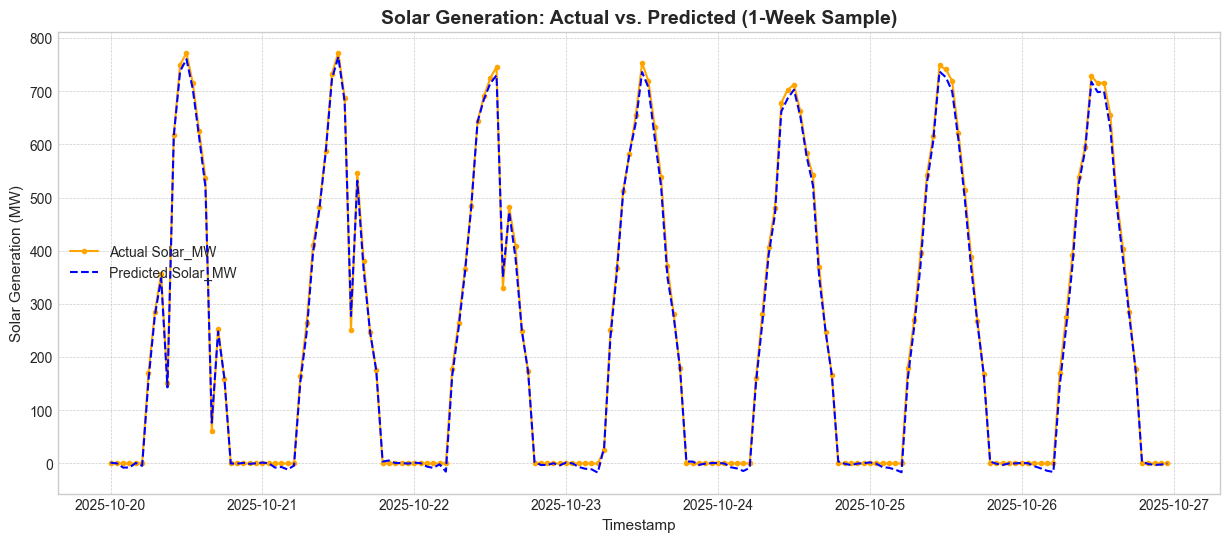

In [ ]:

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
results_df['Timestamp'] = df.loc[y_test.index, 'Timestamp'].values


sample_results = results_df.iloc[:24*7]

plt.figure(figsize=(15, 6))
plt.plot(sample_results['Timestamp'], sample_results['Actual'], label='Actual Solar_MW', color='orange', marker='.')
plt.plot(sample_results['Timestamp'], sample_results['Predicted'], label='Predicted Solar_MW', color='blue', linestyle='--')
plt.title('Solar Generation: Actual vs. Predicted (1-Week Sample)', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=11)
plt.ylabel('Solar Generation (MW)', fontsize=11)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [12]:
print(X_train.columns.tolist())

['Temperature_C', 'Cloud_Cover_Pct', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos']


In [15]:
model_path = '../models/solar_forecaster_v1.joblib'
joblib.dump(model, model_path)

print(f"✓ Model saved to {model_path}")

✓ Model saved to ../models/solar_forecaster_v1.joblib
